In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
df = pd.read_csv(r"C:\Users\Muskan\OneDrive\Documents\Financial Statements.csv")

In [3]:
df.head()

,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
0,2022,AAPL,IT,2066.94,394328.0,170782.0,99803.0,6.11,130541.0,50672.0,...,0.8794,2.3695,196.9589,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028
1,2021,AAPL,IT,2913.28,365817.0,152836.0,94680.0,5.61,120233.0,63090.0,...,1.0746,1.9768,150.0713,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979
2,2020,AAPL,IT,2255.97,274515.0,104956.0,57411.0,3.28,77344.0,65339.0,...,1.3636,1.7208,87.8664,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336
3,2019,AAPL,IT,1304.76,260174.0,98392.0,55256.0,2.97,76477.0,90488.0,...,1.5401,1.1940,61.0645,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122
4,2018,AAPL,IT,748.54,265595.0,101839.0,59531.0,2.98,81801.0,107147.0,...,1.1329,1.0685,55.5601,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426


In [4]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap(in B USD)                 160 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

,Year,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,Cash Flow from Operating,Cash Flow from Investing,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
count,161.000000,160.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,...,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,1.610000e+02,161.000000
mean,2015.608696,337.604313,75862.600758,37383.463124,12276.607076,0.982886,20174.023974,57178.005273,20790.317839,-9581.533232,...,2.035368,0.645520,12.432402,7.780479,11.881350,13.684964,0.192825,24.247542,1.457188e+05,2.231317
std,4.049960,541.102812,90786.895983,41669.093697,19417.421119,8.874504,26342.029803,54098.208311,27300.212516,16196.808177,...,1.660894,2.507177,44.777292,8.802462,93.384692,13.401767,15.412788,109.982817,2.234389e+05,1.959139
min,2009.000000,0.040000,3326.445000,1174.269000,-12244.000000,-90.480000,-6860.000000,-8210.300000,-39392.270000,-59611.000000,...,0.220500,-11.775000,-212.606900,-23.723600,-742.105200,-44.696100,-121.502200,-554.174100,5.420000e+03,-0.355500
25%,2012.000000,41.155000,22820.400000,10396.000000,844.000000,0.340000,2310.000000,12353.000000,3502.000000,-17434.000000,...,1.000000,0.077200,5.080000,0.828200,2.757900,4.827700,-0.361300,6.111800,2.990000e+04,1.261600
50%,2016.000000,113.140000,45992.040000,19561.000000,4757.800000,1.790000,9958.000000,47791.000000,7386.700000,-5904.000000,...,1.341200,0.381800,14.501600,6.641100,13.469400,15.297700,0.265600,19.782200,9.600000e+04,1.812200
75%,2019.000000,357.107500,77849.000000,47722.000000,14136.000000,3.240000,27765.000000,91570.700000,31626.000000,-981.600000,...,2.473400,0.891400,28.189300,14.701600,20.472300,22.934500,0.935400,36.980600,1.470000e+05,2.442600
max,2023.000000,2913.280000,513983.000000,225152.000000,99803.000000,14.980000,130541.000000,256144.000000,122151.000000,49749.000000,...,10.617800,9.332800,196.958900,31.154100,884.860500,36.686300,137.328700,1197.727000,1.608000e+06,8.002800


In [5]:
df.columns = df.columns.str.strip()


In [6]:
df.columns


Index(['Year', 'Company', 'Category', 'Market Cap(in B USD)', 'Revenue',
       'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA',
       'Share Holder Equity', 'Cash Flow from Operating',
       'Cash Flow from Investing', 'Cash Flow from Financial Activities',
       'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI',
       'Net Profit Margin', 'Free Cash Flow per Share',
       'Return on Tangible Equity', 'Number of Employees',
       'Inflation Rate(in US)'],
      dtype='object')

In [7]:
df.isnull().sum()


Year                                   0
Company                                0
Category                               0
Market Cap(in B USD)                   1
Revenue                                0
Gross Profit                           0
Net Income                             0
Earning Per Share                      0
EBITDA                                 0
Share Holder Equity                    0
Cash Flow from Operating               0
Cash Flow from Investing               0
Cash Flow from Financial Activities    0
Current Ratio                          0
Debt/Equity Ratio                      0
ROE                                    0
ROA                                    0
ROI                                    0
Net Profit Margin                      0
Free Cash Flow per Share               0
Return on Tangible Equity              0
Number of Employees                    0
Inflation Rate(in US)                  0
dtype: int64

In [13]:
print(df.columns.tolist())


['Year', 'Company', 'Category', 'Market Cap(in B USD)', 'Revenue', 'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA', 'Share Holder Equity', 'Cash Flow from Operating', 'Cash Flow from Investing', 'Cash Flow from Financial Activities', 'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI', 'Net Profit Margin', 'Free Cash Flow per Share', 'Return on Tangible Equity', 'Number of Employees', 'Inflation Rate(in US)']


In [15]:
df.columns = (
    df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
)



In [16]:
print(df.columns.tolist())


['year', 'company', 'category', 'market_capin_b_usd', 'revenue', 'gross_profit', 'net_income', 'earning_per_share', 'ebitda', 'share_holder_equity', 'cash_flow_from_operating', 'cash_flow_from_investing', 'cash_flow_from_financial_activities', 'current_ratio', 'debt_equity_ratio', 'roe', 'roa', 'roi', 'net_profit_margin', 'free_cash_flow_per_share', 'return_on_tangible_equity', 'number_of_employees', 'inflation_ratein_us']


In [17]:
df.isnull().sum()


year                                   0
company                                0
category                               0
market_capin_b_usd                     0
revenue                                0
gross_profit                           0
net_income                             0
earning_per_share                      0
ebitda                                 0
share_holder_equity                    0
cash_flow_from_operating               0
cash_flow_from_investing               0
cash_flow_from_financial_activities    0
current_ratio                          0
debt_equity_ratio                      0
roe                                    0
roa                                    0
roi                                    0
net_profit_margin                      0
free_cash_flow_per_share               0
return_on_tangible_equity              0
number_of_employees                    0
inflation_ratein_us                    0
dtype: int64

In [20]:
df = df.sort_values(by=['company', 'year'])

df['revenue_growth_%'] = (
    df.groupby('company')['revenue']
      .pct_change() * 100
)



In [21]:
df['net_income_growth_%'] = (
    df.groupby('company')['net_income']
      .pct_change() * 100
)


In [22]:
df['ebitda_margin_%'] = (df['ebitda'] / df['revenue']) * 100


In [23]:
df['equity_growth_%'] = (
    df.groupby('company')['share_holder_equity']
      .pct_change() * 100
)


In [24]:
df['risk_score'] = (
    df['debt_equity_ratio'] * 0.5
    + (1 / df['current_ratio']) * 0.3
    + (df['net_income'] < 0) * 5
)


In [25]:
df[['company','year','revenue_growth_%','net_income_growth_%','risk_score']].head(10)


,company,year,revenue_growth_%,net_income_growth_%,risk_score
13,AAPL,2009,NaN,NaN,0.109389
12,AAPL,2010,52.021909,70.163934,0.149157
11,AAPL,2011,65.962438,84.985371,0.186521
10,AAPL,2012,44.581474,60.994522,0.200562
9,AAPL,2013,9.202086,-11.252486,0.247370
8,AAPL,2014,6.953952,6.677107,0.435952
7,AAPL,2015,27.856342,35.140471,0.540063
6,AAPL,2016,-7.734206,-14.434206,0.561079
5,AAPL,2017,6.304518,5.830980,0.666591
4,AAPL,2018,15.861958,23.122583,0.799057


In [26]:
company_summary = df.groupby('company').agg({
    'revenue_growth_%': 'mean',
    'net_income_growth_%': 'mean',
    'roe': 'mean',
    'debt_equity_ratio': 'mean',
    'risk_score': 'mean'
}).reset_index()

company_summary.head()


,company,revenue_growth_%,net_income_growth_%,roe,debt_equity_ratio,risk_score
0,AAPL,20.425742,25.251859,61.273936,0.775993,0.611529
1,AIG,-1.810035,-4225.915813,4.069250,0.558186,2.364807
2,AMZN,26.678023,-65.868426,11.197943,0.422207,1.553845
3,BCS,-2.653405,-61.604957,5.043157,6.287986,4.872564
4,GOOG,21.261709,24.943752,17.108457,0.046907,0.095878


In [27]:
def classify_company(row):
    if row['revenue_growth_%'] > 10 and row['roe'] > 15:
        return 'High Growth'
    elif row['risk_score'] > 3:
        return 'High Risk'
    elif row['revenue_growth_%'] < 0:
        return 'Declining'
    else:
        return 'Stable'

company_summary['segment'] = company_summary.apply(classify_company, axis=1)

company_summary.head()


,company,revenue_growth_%,net_income_growth_%,roe,debt_equity_ratio,risk_score,segment
0,AAPL,20.425742,25.251859,61.273936,0.775993,0.611529,High Growth
1,AIG,-1.810035,-4225.915813,4.069250,0.558186,2.364807,Declining
2,AMZN,26.678023,-65.868426,11.197943,0.422207,1.553845,Stable
3,BCS,-2.653405,-61.604957,5.043157,6.287986,4.872564,High Risk
4,GOOG,21.261709,24.943752,17.108457,0.046907,0.095878,High Growth


In [28]:
company_summary['segment'].value_counts()


Stable         6
High Growth    3
High Risk      2
Declining      1
Name: segment, dtype: int64

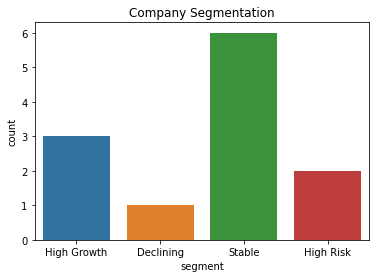

In [29]:
sns.countplot(x='segment', data=company_summary)
plt.title("Company Segmentation")
plt.show()


In [30]:
df['financial_strength_index'] = (
    df['roe'] * 0.3 +
    df['net_profit_margin'] * 0.3 +
    df['current_ratio'] * 0.2 -
    df['debt_equity_ratio'] * 0.2
)


In [31]:
company_summary = df.groupby('company').agg({
    'revenue_growth_%': 'mean',
    'net_income_growth_%': 'mean',
    'roe': 'mean',
    'current_ratio': 'mean',
    'debt_equity_ratio': 'mean',
    'financial_strength_index': 'mean'
}).reset_index()

company_summary.head()


,company,revenue_growth_%,net_income_growth_%,roe,current_ratio,debt_equity_ratio,financial_strength_index
0,AAPL,20.425742,25.251859,61.273936,1.453207,0.775993,25.277408
1,AIG,-1.810035,-4225.915813,4.069250,1.000000,0.558186,2.717552
2,AMZN,26.678023,-65.868426,11.197943,1.114400,0.422207,4.203959
3,BCS,-2.653405,-61.604957,5.043157,1.000000,6.287986,2.939843
4,GOOG,21.261709,24.943752,17.108457,4.710343,0.046907,12.933071


In [32]:
company_summary.sort_values(by='financial_strength_index', ascending=False).head(10)


,company,revenue_growth_%,net_income_growth_%,roe,current_ratio,debt_equity_ratio,financial_strength_index
0,AAPL,20.425742,25.251859,61.273936,1.453207,0.775993,25.277408
7,MSFT,9.774863,19.589597,32.427673,2.379913,0.425213,18.338990
4,GOOG,21.261709,24.943752,17.108457,4.710343,0.046907,12.933071
5,INTC,5.196116,15.717209,19.912079,2.106207,0.294171,12.753226
8,NVDA,17.646821,12.982180,19.113547,5.069060,0.229960,11.964382
10,PYPL,16.923942,14.924354,13.703650,1.374350,0.226938,8.535612
11,SHLDQ,-10.499115,-242.245010,16.694970,1.129060,-0.304400,4.248201
2,AMZN,26.678023,-65.868426,11.197943,1.114400,0.422207,4.203959
3,BCS,-2.653405,-61.604957,5.043157,1.000000,6.287986,2.939843
1,AIG,-1.810035,-4225.915813,4.069250,1.000000,0.558186,2.717552


In [34]:
sector_summary = df.groupby('category').agg({
    'revenue_growth_%': 'mean',
    'net_income_growth_%': 'mean',
    'roe': 'mean',
    'debt_equity_ratio': 'mean',
    'financial_strength_index': 'mean'
}).reset_index()

sector_summary.sort_values(by='financial_strength_index', ascending=False)


,category,revenue_growth_%,net_income_growth_%,roe,debt_equity_ratio,financial_strength_index
6,IT,16.969624,23.169932,36.831828,0.416251,18.837943
2,ELEC,11.652037,14.299046,19.499045,0.260959,12.345203
4,FinTech,16.923942,14.924354,13.703650,0.226938,8.535612
5,Finance,-10.499115,-242.245010,16.694970,-0.304400,4.248201
7,LOGI,26.678023,-65.868426,11.197943,0.422207,4.203959
0,BANK,-2.653405,-61.604957,5.043157,6.287986,2.939843
1,Bank,-1.810035,-4225.915813,4.069250,0.558186,2.717552
8,Manufacturing,3.866255,-189.698889,-8.768300,1.250129,-3.155904
3,FOOD,0.473809,3.983505,-42.205129,-2.835779,-4.985151


In [35]:
company_dashboard = df.groupby('company').agg({
    'revenue': 'mean',
    'net_income': 'mean',
    'roe': 'mean',
    'current_ratio': 'mean',
    'debt_equity_ratio': 'mean',
    'revenue_growth_%': 'mean',
    'net_income_growth_%': 'mean',
    'financial_strength_index': 'mean'
}).reset_index()

company_dashboard.head()


,company,revenue,net_income,roe,current_ratio,debt_equity_ratio,revenue_growth_%,net_income_growth_%,financial_strength_index
0,AAPL,211829.214286,48611.642857,61.273936,1.453207,0.775993,20.425742,25.251859,25.277408
1,AIG,59103.857143,2991.428571,4.069250,1.000000,0.558186,-1.810035,-4225.915813,2.717552
2,AMZN,188247.142857,5879.500000,11.197943,1.114400,0.422207,26.678023,-65.868426,4.203959
3,BCS,36806.344286,2875.013943,5.043157,1.000000,6.287986,-2.653405,-61.604957,2.939843
4,GOOG,111159.142857,25120.500000,17.108457,4.710343,0.046907,21.261709,24.943752,12.933071


In [36]:
df.to_csv("cleaned_financial_data.csv", index=False)
company_dashboard.to_csv("company_summary_dashboard.csv", index=False)


In [37]:
import os
os.getcwd()


'C:\\Users\\Muskan'